# 1章 入門チュートリアル

## 生データからのイベント解析

### データの読み込み

In [1]:
import numpy as np

import mne

sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file)
raw.crop(tmax=60).load_data()

Opening raw data file /Users/r.shimbo/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 36037  =      0.000 ...    60.000 secs...


/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Raw | sample_audvis_raw.fif, 376 x 36038 (60.0 s), ~106.6 MiB, data loaded>

### STIMチャンネルとは

Using matplotlib as 2D backend.


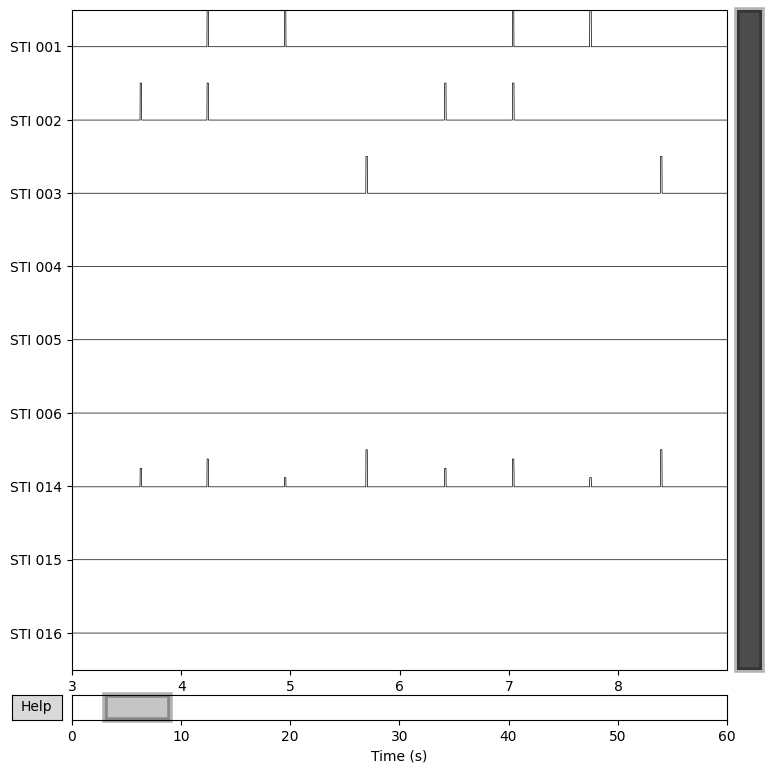

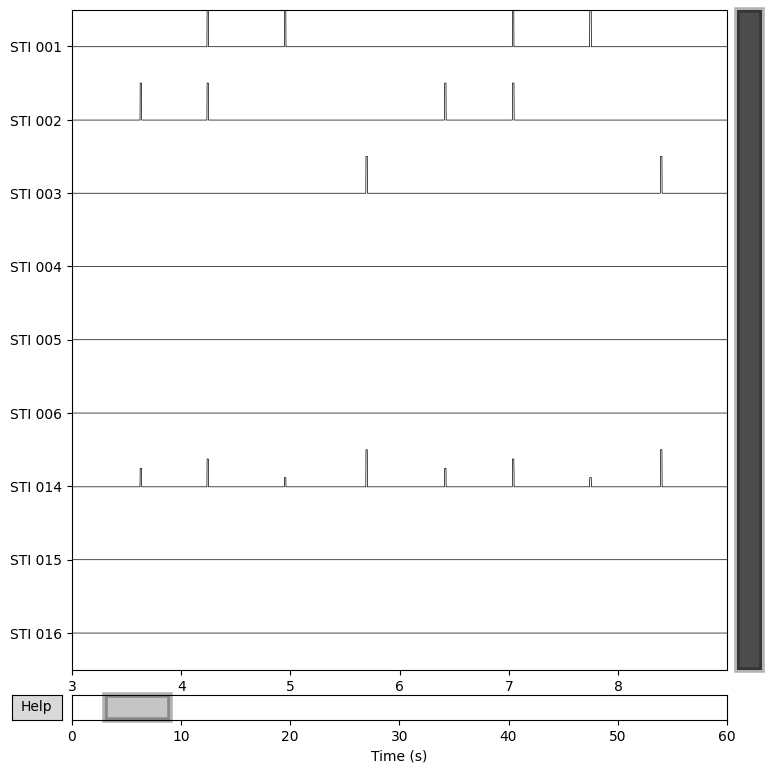

In [2]:
# プログラム1

raw.copy().pick(picks="stim").plot(start=3, duration=6)

### STIMチャネル信号をイベント配列に変換する

In [ ]:
# プログラム2

events = mne.find_events(raw, stim_channel="STI 014")
print(events[:5])  # show the first 5

Finding events on: STI 014
86 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
[[27977     0     2]
 [28345     0     3]
 [28771     0     1]
 [29219     0     4]
 [29652     0     2]]


### 埋め込みイベントを注釈として読み込む

In [ ]:
# プログラム3

testing_data_folder = mne.datasets.testing.data_path()
eeglab_raw_file = testing_data_folder / "EEGLAB" / "test_raw.set"
eeglab_raw = mne.io.read_raw_eeglab(eeglab_raw_file)
print(eeglab_raw.annotations)

Using default location ~/mne_data for testing...
Dataset testing version 0.0 out of date, latest version is 0.173
Fetching 1 file for the testing dataset ...


0.00B [00:00, ?B/s]     
Untarring contents of '/Users/r.shimbo/mne_data/mne-testing-data-0.173.tar.gz' to '/Users/r.shimbo/mne_data'


Download complete in 02m44s (1078.0 MB)
Reading /Users/r.shimbo/mne_data/MNE-testing-data/EEGLAB/test_raw.fdt
<Annotations | 154 segments: rt (74), square (80)>


In [ ]:
# プログラム4

print(len(eeglab_raw.annotations))
print(set(eeglab_raw.annotations.duration))
print(set(eeglab_raw.annotations.description))
print(eeglab_raw.annotations.onset[0])

154
{np.float64(0.0)}
{np.str_('rt'), np.str_('square')}
1.000068


### イベント配列とアノテーションオブジェクト間の変換

In [6]:
# プログラム5

events_from_annot, event_dict = mne.events_from_annotations(eeglab_raw)
print(event_dict)
print(events_from_annot[:5])

Used Annotations descriptions: [np.str_('rt'), np.str_('square')]
{np.str_('rt'): 1, np.str_('square'): 2}
[[128   0   2]
 [217   0   2]
 [267   0   1]
 [602   0   2]
 [659   0   1]]


In [7]:
# プログラム6

custom_mapping = {"rt": 77, "square": 42}
(events_from_annot, event_dict) = mne.events_from_annotations(
    eeglab_raw, event_id=custom_mapping
)
print(event_dict)
print(events_from_annot[:5])

Used Annotations descriptions: [np.str_('rt'), np.str_('square')]
{np.str_('rt'): 77, np.str_('square'): 42}
[[128   0  42]
 [217   0  42]
 [267   0  77]
 [602   0  42]
 [659   0  77]]


In [8]:
# プログラム7

mapping = {
    1: "auditory/left",
    2: "auditory/right",
    3: "visual/left",
    4: "visual/right",
    5: "smiley",
    32: "buttonpress",
}
annot_from_events = mne.annotations_from_events(
    events=events,
    event_desc=mapping,
    sfreq=raw.info["sfreq"],
    orig_time=raw.info["meas_date"],
)
raw.set_annotations(annot_from_events)

<Raw | sample_audvis_raw.fif, 376 x 36038 (60.0 s), ~106.6 MiB, data loaded>

/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: divide by zero encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: overflow encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: invalid value encountered in matmul
  data = self.mne.projector @ data


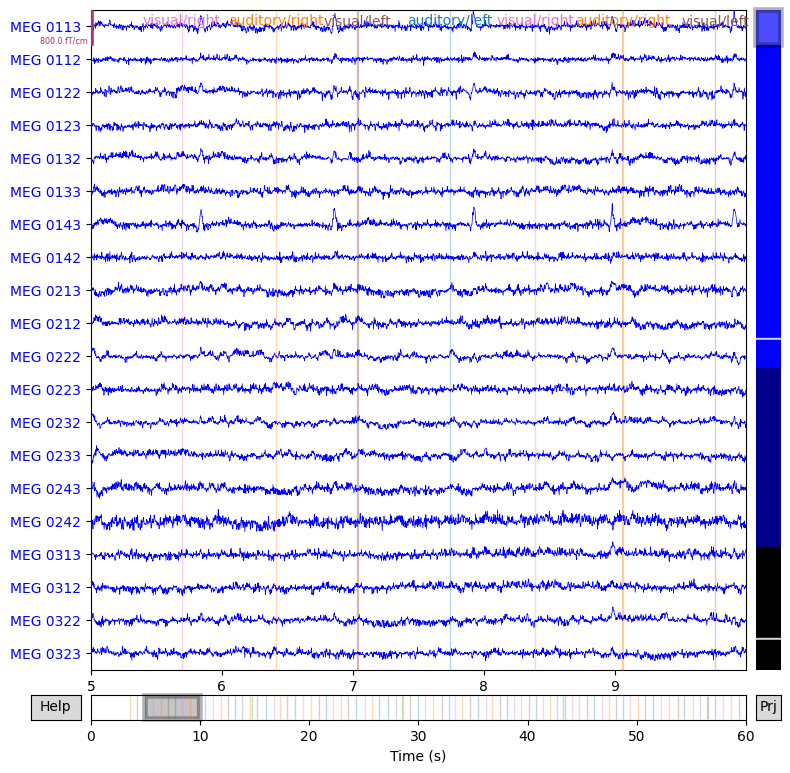

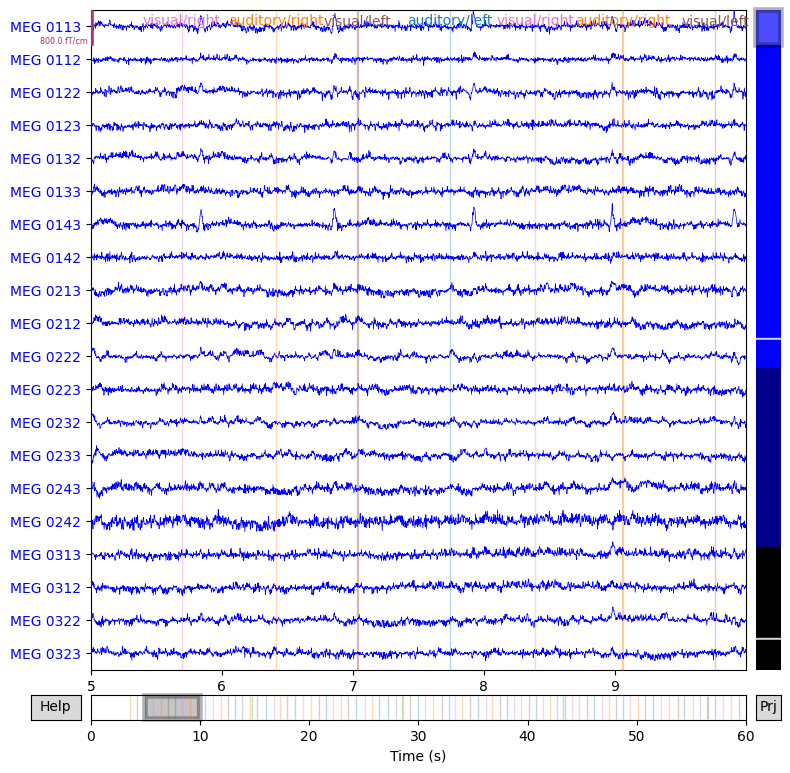

In [ ]:
# プログラム8

raw.plot(start=5, duration=5)

### アノテーションごとに複数のイベントを作成する

In [10]:
# プログラム9

# create the REM annotations
rem_annot = mne.Annotations(onset=[5, 41], duration=[16, 11], description=["REM"] * 2)
raw.set_annotations(rem_annot)
(rem_events, rem_event_dict) = mne.events_from_annotations(raw, chunk_duration=1.5)

Used Annotations descriptions: [np.str_('REM')]


In [11]:
# プログラム10

print(np.round((rem_events[:, 0] - raw.first_samp) / raw.info["sfreq"], 3))

[ 5.     6.5    8.     9.5   11.    12.501 14.001 15.501 16.999 18.499
 41.    42.5   44.    45.5   47.    48.5   50.   ]
